# Brain Stroke CT Dataset — Exploration

**Dataset structure:**
```
Brain_Stroke_CT_Dataset/
├── Bleeding/     → DICOM, PNG, OVERLAY
├── Ischemia/     → DICOM, PNG, OVERLAY
├── Normal/       → DICOM, PNG
└── External_Test/ → DICOM, PNG, OVERLAY, MASKS
```

## 0. Imports & Paths

In [1]:
from gettext import install
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from PIL import Image
import pydicom
import cv2
from collections import defaultdict

# ── Paths ──────────────────────────────────────────────────────────────────
ROOT = Path(r'C:/Users/Beddad/Desktop/Brain_Scan/Brain_Stroke_CT_Dataset')

CLASSES = ['Bleeding', 'Ischemia', 'Normal']
FORMATS = ['DICOM', 'PNG', 'OVERLAY']   # MASKS only in External_Test

paths = {
    cls: {
        fmt: ROOT / cls / fmt
        for fmt in FORMATS if (ROOT / cls / fmt).exists()
    }
    for cls in CLASSES
}
paths['External_Test'] = {fmt: ROOT / 'External_Test' / fmt
                          for fmt in ['DICOM', 'PNG', 'OVERLAY', 'MASKS']}

print('Paths verified:')
for cls, fmts in paths.items():
    for fmt, p in fmts.items():
        print(f'  {cls}/{fmt}: {"OK" if p.exists() else "MISSING"} ({p})')

Paths verified:
  Bleeding/DICOM: OK (C:\Users\Beddad\Desktop\Brain_Scan\Brain_Stroke_CT_Dataset\Bleeding\DICOM)
  Bleeding/PNG: OK (C:\Users\Beddad\Desktop\Brain_Scan\Brain_Stroke_CT_Dataset\Bleeding\PNG)
  Bleeding/OVERLAY: OK (C:\Users\Beddad\Desktop\Brain_Scan\Brain_Stroke_CT_Dataset\Bleeding\OVERLAY)
  Ischemia/DICOM: OK (C:\Users\Beddad\Desktop\Brain_Scan\Brain_Stroke_CT_Dataset\Ischemia\DICOM)
  Ischemia/PNG: OK (C:\Users\Beddad\Desktop\Brain_Scan\Brain_Stroke_CT_Dataset\Ischemia\PNG)
  Ischemia/OVERLAY: OK (C:\Users\Beddad\Desktop\Brain_Scan\Brain_Stroke_CT_Dataset\Ischemia\OVERLAY)
  Normal/DICOM: OK (C:\Users\Beddad\Desktop\Brain_Scan\Brain_Stroke_CT_Dataset\Normal\DICOM)
  Normal/PNG: OK (C:\Users\Beddad\Desktop\Brain_Scan\Brain_Stroke_CT_Dataset\Normal\PNG)
  External_Test/DICOM: OK (C:\Users\Beddad\Desktop\Brain_Scan\Brain_Stroke_CT_Dataset\External_Test\DICOM)
  External_Test/PNG: OK (C:\Users\Beddad\Desktop\Brain_Scan\Brain_Stroke_CT_Dataset\External_Test\PNG)
  External

## 1. File Counts & Class Distribution

In [2]:
counts = {}
for cls, fmts in paths.items():
    counts[cls] = {}
    for fmt, p in fmts.items():
        files = list(p.iterdir()) if p.exists() else []
        counts[cls][fmt] = len(files)

# Print table
print(f"{'Class':<16} {'DICOM':>8} {'PNG':>8} {'OVERLAY':>10} {'MASKS':>8} {'TOTAL':>8}")
print('-' * 60)
for cls, fmts in counts.items():
    d = fmts.get('DICOM', 0)
    p = fmts.get('PNG', 0)
    o = fmts.get('OVERLAY', 0)
    m = fmts.get('MASKS', 0)
    print(f"{cls:<16} {d:>8} {p:>8} {o:>10} {m:>8} {d+p+o+m:>8}")

# PNG counts for classification
png_counts = {cls: counts[cls].get('PNG', 0) for cls in CLASSES}
total_train = sum(png_counts.values())
print(f"\nTraining images (PNG): {total_train}")
for cls, n in png_counts.items():
    print(f"  {cls}: {n} ({100*n/total_train:.1f}%)")

Class               DICOM      PNG    OVERLAY    MASKS    TOTAL
------------------------------------------------------------
Bleeding             1093     1093       1093        0     3279
Ischemia             1130     1130       1130        0     3390
Normal               4427     4427          0        0     8854
External_Test         200      200        200      200      800

Training images (PNG): 6650
  Bleeding: 1093 (16.4%)
  Ischemia: 1130 (17.0%)
  Normal: 4427 (66.6%)


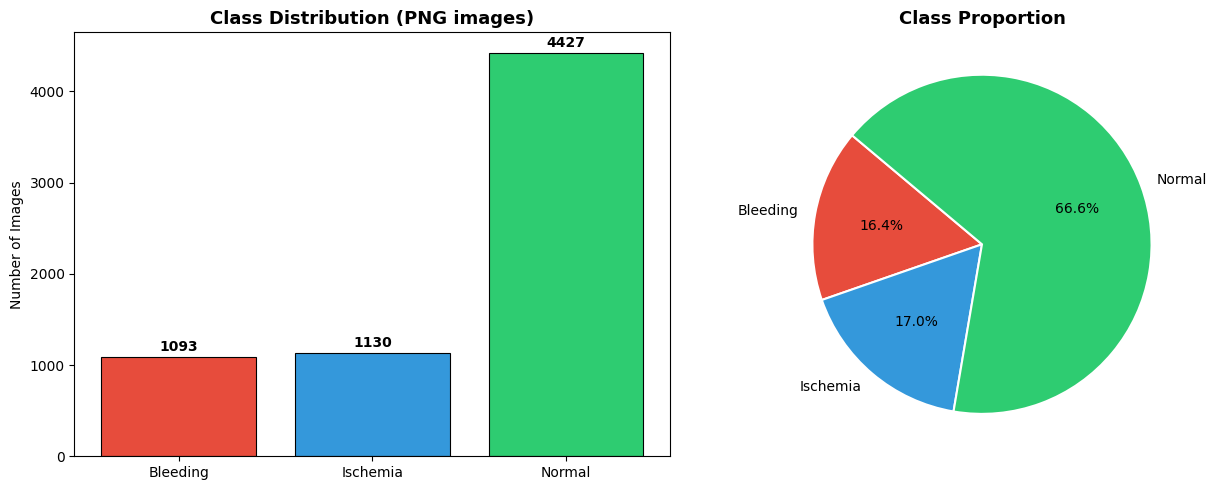

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart
colors = ['#e74c3c', '#3498db', '#2ecc71']
bars = axes[0].bar(png_counts.keys(), png_counts.values(), color=colors, edgecolor='black', linewidth=0.8)
axes[0].set_title('Class Distribution (PNG images)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Images')
for bar, val in zip(bars, png_counts.values()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 str(val), ha='center', va='bottom', fontweight='bold')

# Pie chart
axes[1].pie(png_counts.values(), labels=png_counts.keys(), colors=colors,
            autopct='%1.1f%%', startangle=140,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Class Proportion', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(ROOT.parent / 'class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Sample Images — PNG per Class

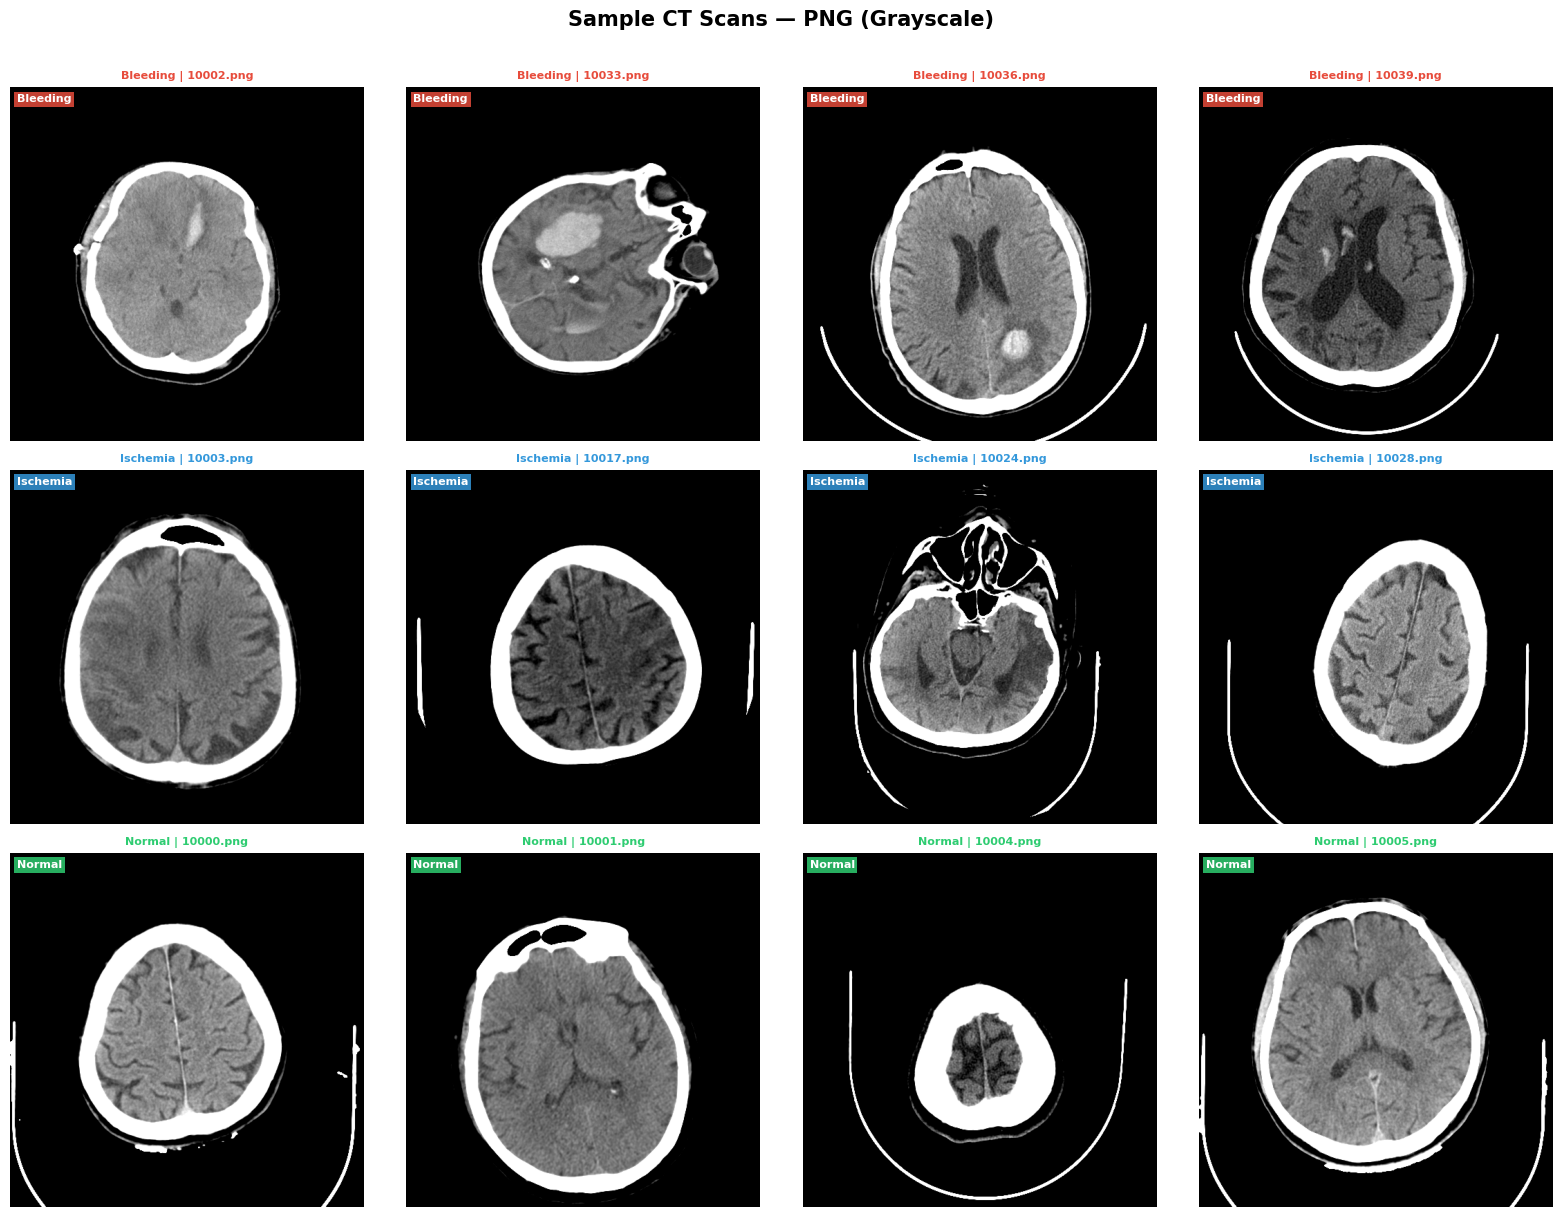

In [5]:
def load_png_samples(class_name, n=4):
    folder = paths[class_name]['PNG']
    files = sorted(folder.iterdir())[:n]
    return [np.array(Image.open(f).convert('L')) for f in files], [f.name for f in files]

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
fig.suptitle('Sample CT Scans — PNG (Grayscale)', fontsize=15, fontweight='bold', y=1.01)

cls_colors = {'Bleeding': '#e74c3c', 'Ischemia': '#3498db', 'Normal': '#2ecc71'}

for row, cls in enumerate(CLASSES):
    imgs, names = load_png_samples(cls, n=4)
    for col, (img, name) in enumerate(zip(imgs, names)):
        ax = axes[row][col]
        ax.imshow(img, cmap='gray')
        ax.set_title(f'{cls} | {name}', fontsize=8, color=cls_colors[cls], fontweight='bold')
        ax.axis('off')

        # In-image class badge for clearer identification
        ax.text(
            0.02, 0.98, cls,
            transform=ax.transAxes,
            ha='left', va='top',
            fontsize=8, fontweight='bold', color='white',
            bbox=dict(facecolor=cls_colors[cls], edgecolor='none', alpha=0.85, pad=2)
        )

        for spine in ax.spines.values():
            spine.set_edgecolor(cls_colors[cls])
            spine.set_linewidth(3)
            spine.set_visible(True)

    axes[row][0].set_ylabel(
        cls, fontsize=12, fontweight='bold',
        color=cls_colors[cls], rotation=90, labelpad=10
    )

plt.tight_layout()
plt.savefig(ROOT.parent / 'sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Overlay / Mask Visualization

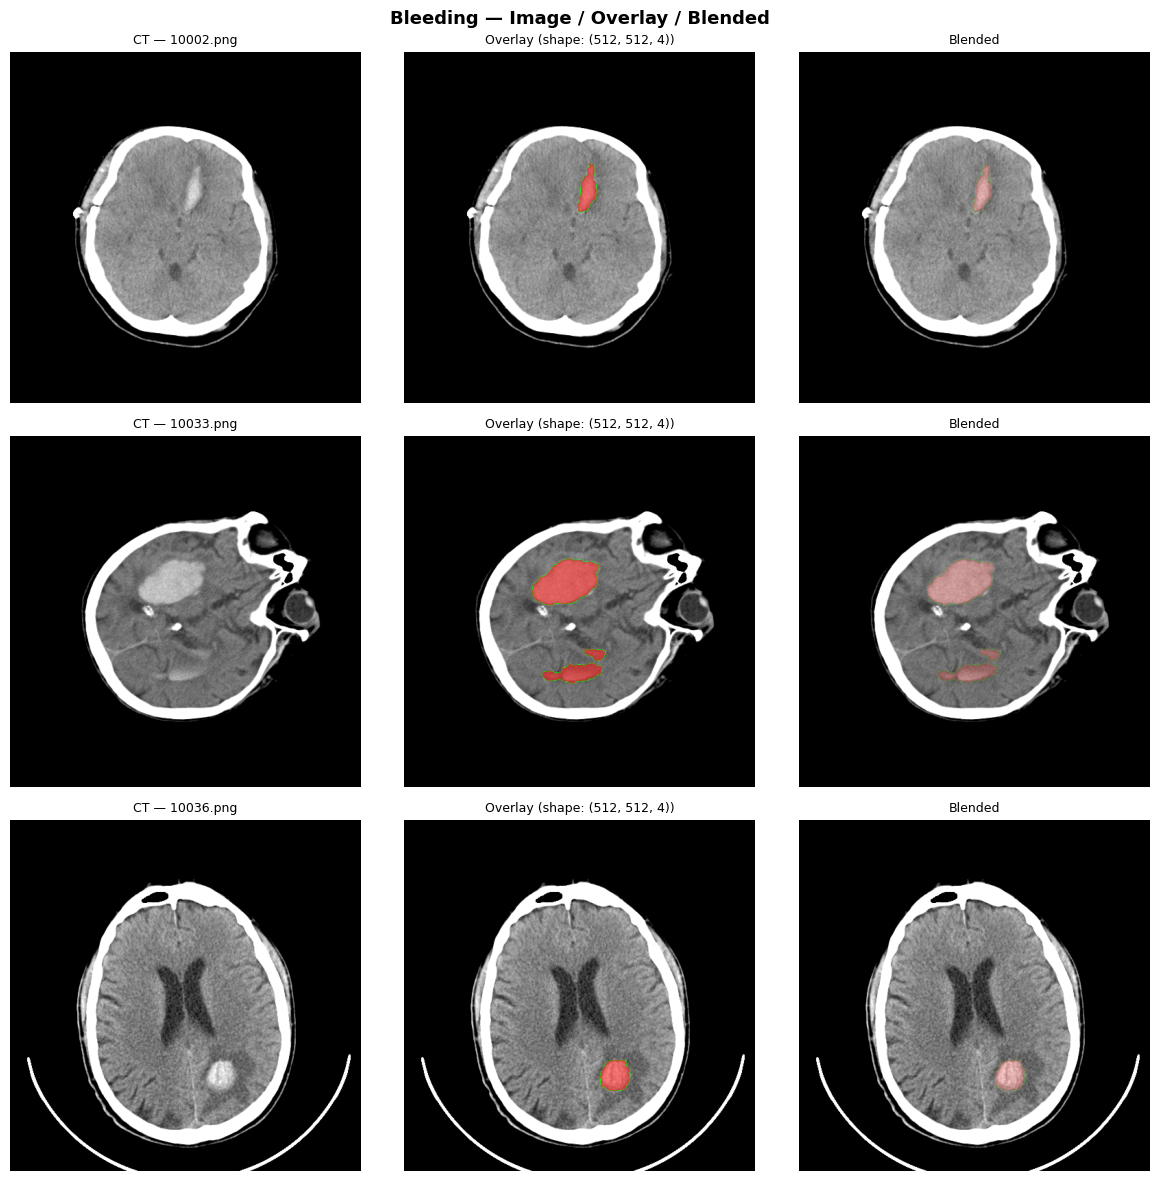

In [6]:
def visualize_overlay(class_name, n=3):
    png_folder = paths[class_name]['PNG']
    ovl_folder = paths[class_name]['OVERLAY']

    # Find matching files
    ovl_files = sorted(ovl_folder.iterdir())[:n]
    fig, axes = plt.subplots(n, 3, figsize=(12, 4*n))
    fig.suptitle(f'{class_name} — Image / Overlay / Blended', fontsize=13, fontweight='bold')

    if n == 1:
        axes = [axes]

    for i, ovl_path in enumerate(ovl_files):
        img_path = png_folder / ovl_path.name
        if not img_path.exists():
            continue

        img = np.array(Image.open(img_path).convert('L'))
        ovl = np.array(Image.open(ovl_path))

        axes[i][0].imshow(img, cmap='gray')
        axes[i][0].set_title(f'CT — {ovl_path.name}', fontsize=9)
        axes[i][0].axis('off')

        axes[i][1].imshow(ovl, cmap='hot' if ovl.ndim == 2 else None)
        axes[i][1].set_title(f'Overlay (shape: {ovl.shape})', fontsize=9)
        axes[i][1].axis('off')

        # Blend
        img_rgb = np.stack([img]*3, axis=-1)
        if ovl.ndim == 2:
            mask_rgb = np.zeros_like(img_rgb)
            mask_rgb[:,:,0] = ovl  # red channel
            ovl_rgb = mask_rgb
        else:
            ovl_rgb = ovl[:,:,:3] if ovl.shape[2] >= 3 else np.stack([ovl[:,:,0]]*3, axis=-1)

        blended = (0.6 * img_rgb + 0.4 * ovl_rgb).astype(np.uint8)
        axes[i][2].imshow(blended)
        axes[i][2].set_title('Blended', fontsize=9)
        axes[i][2].axis('off')

    plt.tight_layout()
    plt.savefig(ROOT.parent / f'overlay_{class_name.lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()

visualize_overlay('Bleeding', n=3)

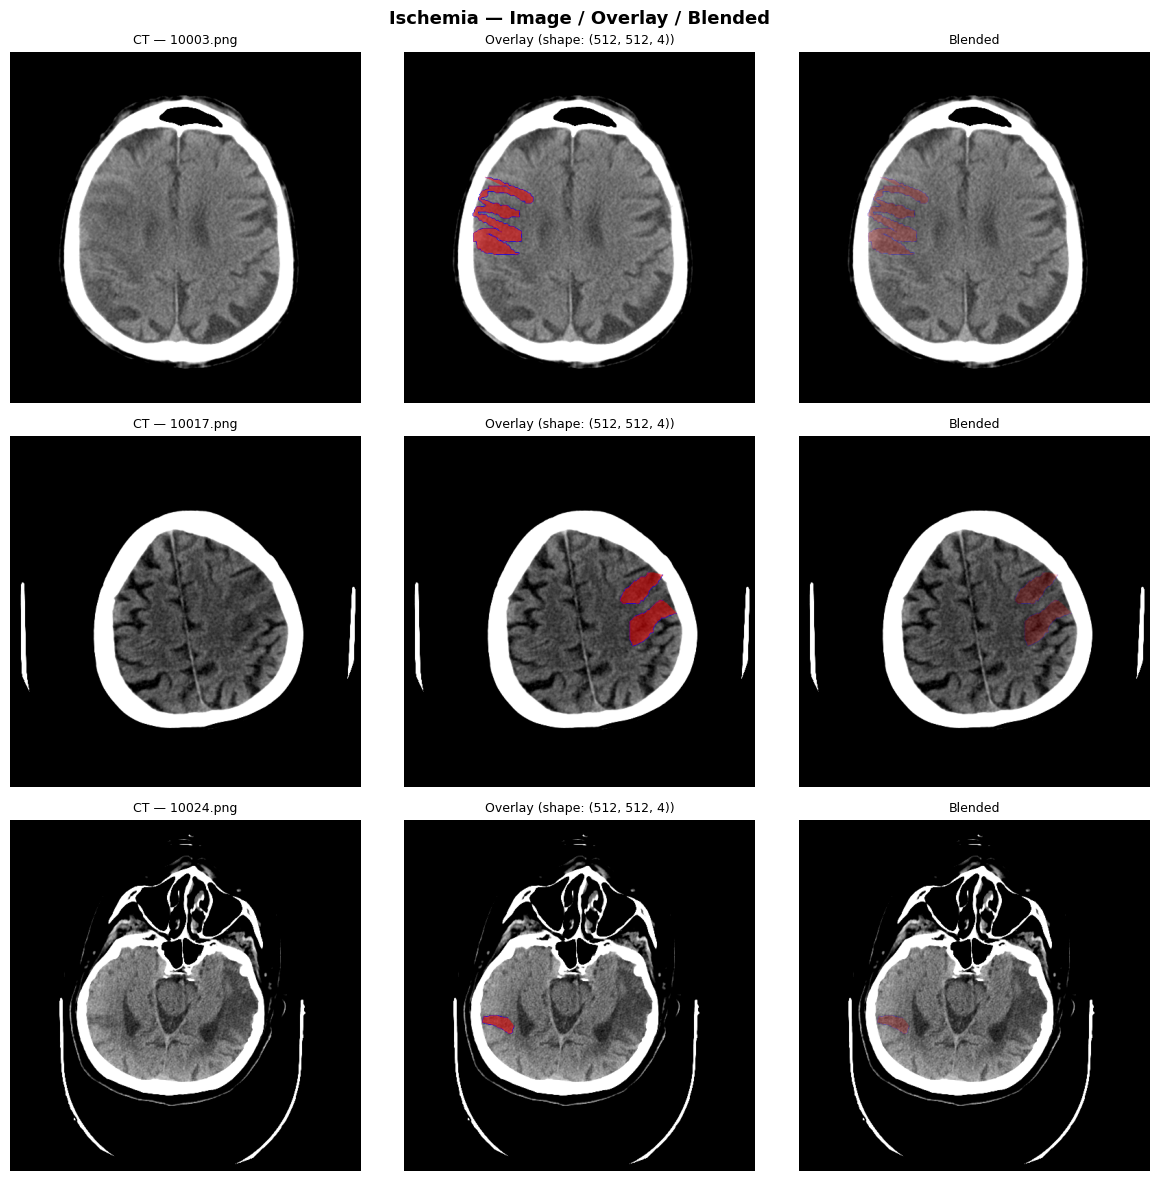

In [7]:
visualize_overlay('Ischemia', n=3)

## 4. External Test Set — Image + Overlay + Mask

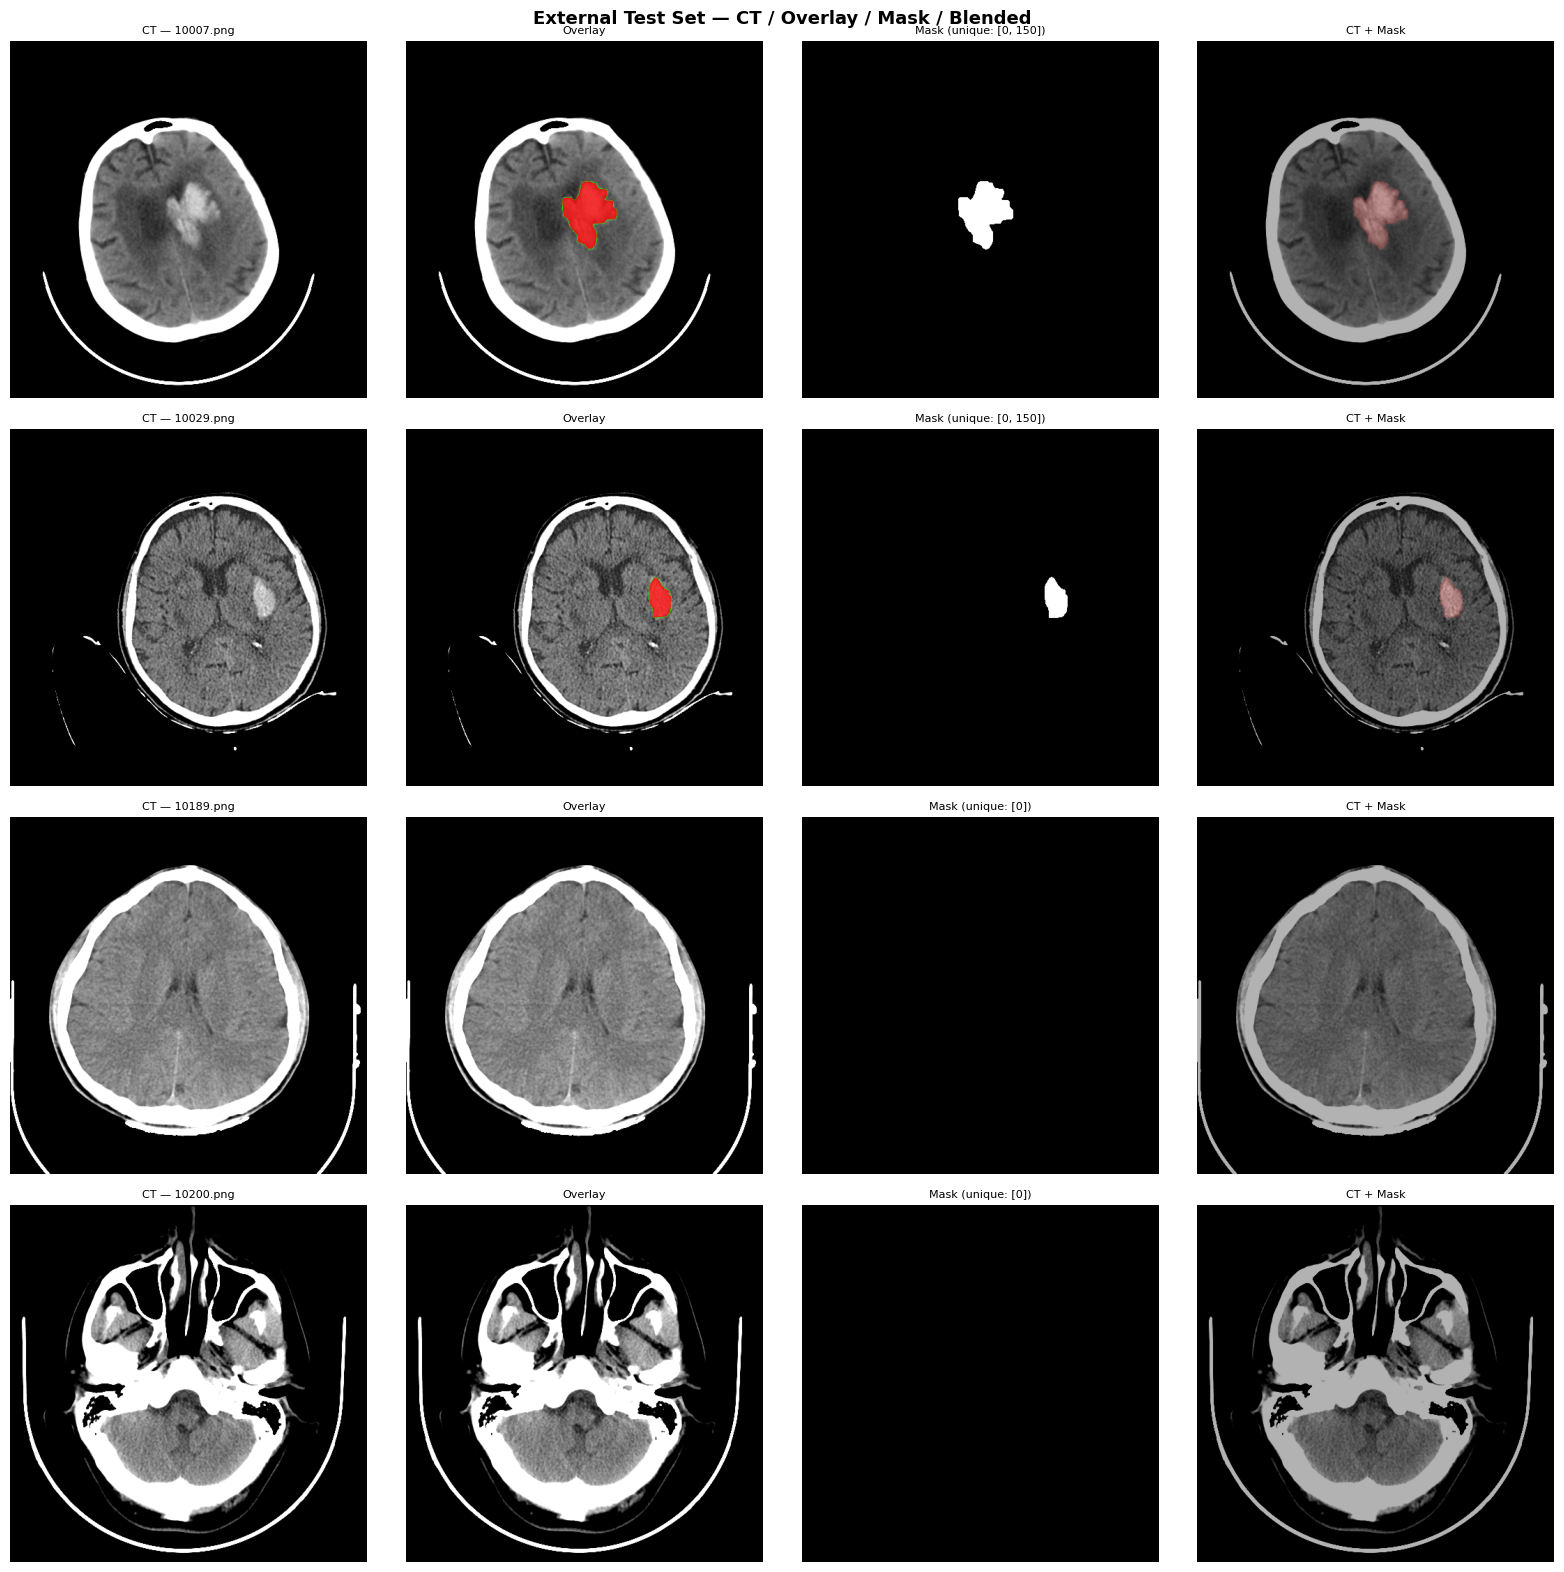

In [8]:
ext = paths['External_Test']
mask_files = sorted(ext['MASKS'].iterdir())[:4]

fig, axes = plt.subplots(4, 4, figsize=(16, 16))
fig.suptitle('External Test Set — CT / Overlay / Mask / Blended', fontsize=13, fontweight='bold')

for i, mask_path in enumerate(mask_files):
    name = mask_path.name
    img_path  = ext['PNG']     / name
    ovl_path  = ext['OVERLAY'] / name

    img  = np.array(Image.open(img_path).convert('L'))  if img_path.exists()  else np.zeros((512,512))
    mask = np.array(Image.open(mask_path).convert('L'))
    ovl  = np.array(Image.open(ovl_path))               if ovl_path.exists()  else np.zeros((512,512,3))

    axes[i][0].imshow(img, cmap='gray');  axes[i][0].set_title(f'CT — {name}', fontsize=8); axes[i][0].axis('off')
    axes[i][1].imshow(ovl);              axes[i][1].set_title('Overlay', fontsize=8);       axes[i][1].axis('off')
    axes[i][2].imshow(mask, cmap='gray'); axes[i][2].set_title(f'Mask (unique: {np.unique(mask).tolist()})', fontsize=8); axes[i][2].axis('off')

    img_rgb = np.stack([img]*3, axis=-1)
    mask_overlay = np.zeros_like(img_rgb)
    mask_overlay[:,:,0] = mask
    blended = np.clip(0.7*img_rgb + 0.3*mask_overlay, 0, 255).astype(np.uint8)
    axes[i][3].imshow(blended); axes[i][3].set_title('CT + Mask', fontsize=8); axes[i][3].axis('off')

plt.tight_layout()
plt.savefig(ROOT.parent / 'external_test_samples.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Image Properties (Size, Channels, Pixel Stats)

In [9]:
print("Image properties per class (first 10 samples):")
print(f"{'Class':<16} {'Shape':>15} {'Min':>6} {'Max':>6} {'Mean':>8} {'Std':>8}")
print('-' * 65)

for cls in CLASSES:
    files = sorted(paths[cls]['PNG'].iterdir())[:10]
    shapes, mins, maxs, means, stds = [], [], [], [], []
    for f in files:
        img = np.array(Image.open(f))
        shapes.append(img.shape)
        mins.append(img.min())
        maxs.append(img.max())
        means.append(img.mean())
        stds.append(img.std())
    unique_shapes = set(str(s) for s in shapes)
    print(f"{cls:<16} {str(unique_shapes):>15} {np.mean(mins):>6.0f} {np.mean(maxs):>6.0f} "
          f"{np.mean(means):>8.2f} {np.mean(stds):>8.2f}")

Image properties per class (first 10 samples):
Class                      Shape    Min    Max     Mean      Std
-----------------------------------------------------------------
Bleeding         {'(512, 512, 4)'}      0    255    99.77   111.82
Ischemia         {'(562, 512, 4)', '(512, 512, 4)', '(552, 512, 4)'}      0    255    96.37   112.59
Normal           {'(512, 512, 4)'}      0    255   101.08   113.12


## 6. Pixel Intensity Distributions

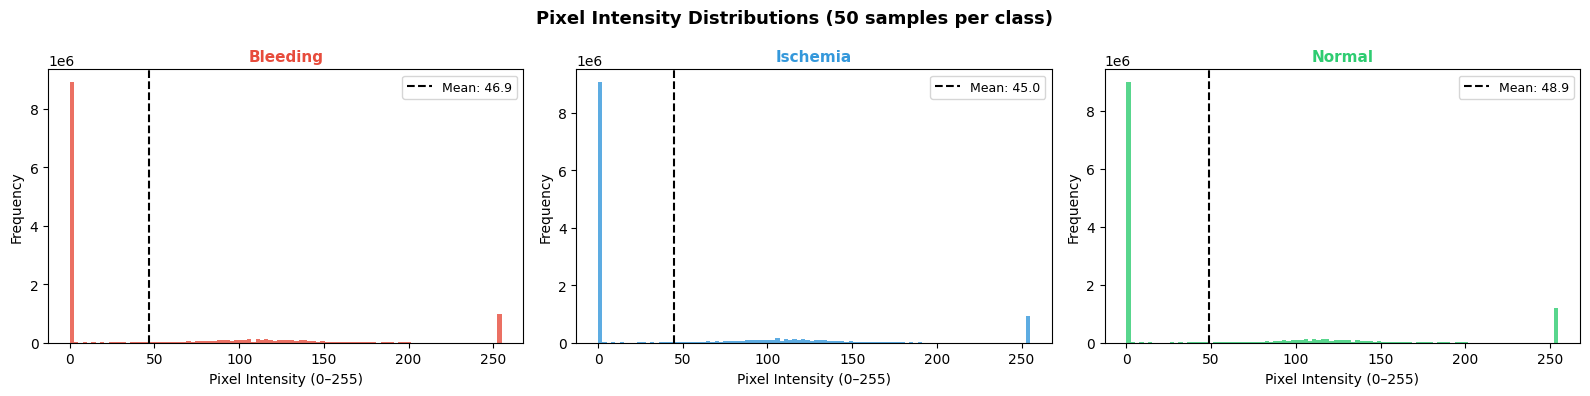

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=False)
fig.suptitle('Pixel Intensity Distributions (50 samples per class)', fontsize=13, fontweight='bold')

cls_colors = {'Bleeding': '#e74c3c', 'Ischemia': '#3498db', 'Normal': '#2ecc71'}

for ax, cls in zip(axes, CLASSES):
    files = sorted(paths[cls]['PNG'].iterdir())[:50]
    all_pixels = np.concatenate([np.array(Image.open(f).convert('L')).ravel() for f in files])
    ax.hist(all_pixels, bins=100, color=cls_colors[cls], alpha=0.8, edgecolor='none')
    ax.set_title(cls, fontsize=11, fontweight='bold', color=cls_colors[cls])
    ax.set_xlabel('Pixel Intensity (0–255)')
    ax.set_ylabel('Frequency')
    ax.axvline(all_pixels.mean(), color='black', linestyle='--', linewidth=1.5,
               label=f'Mean: {all_pixels.mean():.1f}')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(ROOT.parent / 'pixel_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. DICOM Metadata Inspection

In [11]:
DICOM_TAGS = [
    'PatientID', 'Modality', 'StudyDescription', 'SeriesDescription',
    'Rows', 'Columns', 'PixelSpacing', 'SliceThickness',
    'WindowCenter', 'WindowWidth', 'RescaleIntercept', 'RescaleSlope',
    'BitsAllocated', 'BitsStored', 'PhotometricInterpretation'
]

for cls in CLASSES:
    dcm_folder = paths[cls]['DICOM']
    sample_dcm = sorted(dcm_folder.iterdir())[0]
    ds = pydicom.dcmread(sample_dcm, stop_before_pixels=True)
    print(f"\n{'='*50}")
    print(f"Class: {cls} — {sample_dcm.name}")
    print('='*50)
    for tag in DICOM_TAGS:
        val = getattr(ds, tag, 'N/A')
        print(f"  {tag:<30}: {val}")


Class: Bleeding — 10002.dcm
  PatientID                     : N/A
  Modality                      : N/A
  StudyDescription              : N/A
  SeriesDescription             : N/A
  Rows                          : 512
  Columns                       : 512
  PixelSpacing                  : [0.565, 0.565]
  SliceThickness                : 3.0
  WindowCenter                  : 40
  WindowWidth                   : 120
  RescaleIntercept              : 0
  RescaleSlope                  : 1
  BitsAllocated                 : 16
  BitsStored                    : 16
  PhotometricInterpretation     : MONOCHROME2

Class: Ischemia — 10003.dcm
  PatientID                     : N/A
  Modality                      : N/A
  StudyDescription              : N/A
  SeriesDescription             : N/A
  Rows                          : 512
  Columns                       : 512
  PixelSpacing                  : [0.444, 0.444]
  SliceThickness                : 5.0
  WindowCenter                  : 40
  Window

## 8. DICOM vs PNG — Hounsfield Unit Comparison

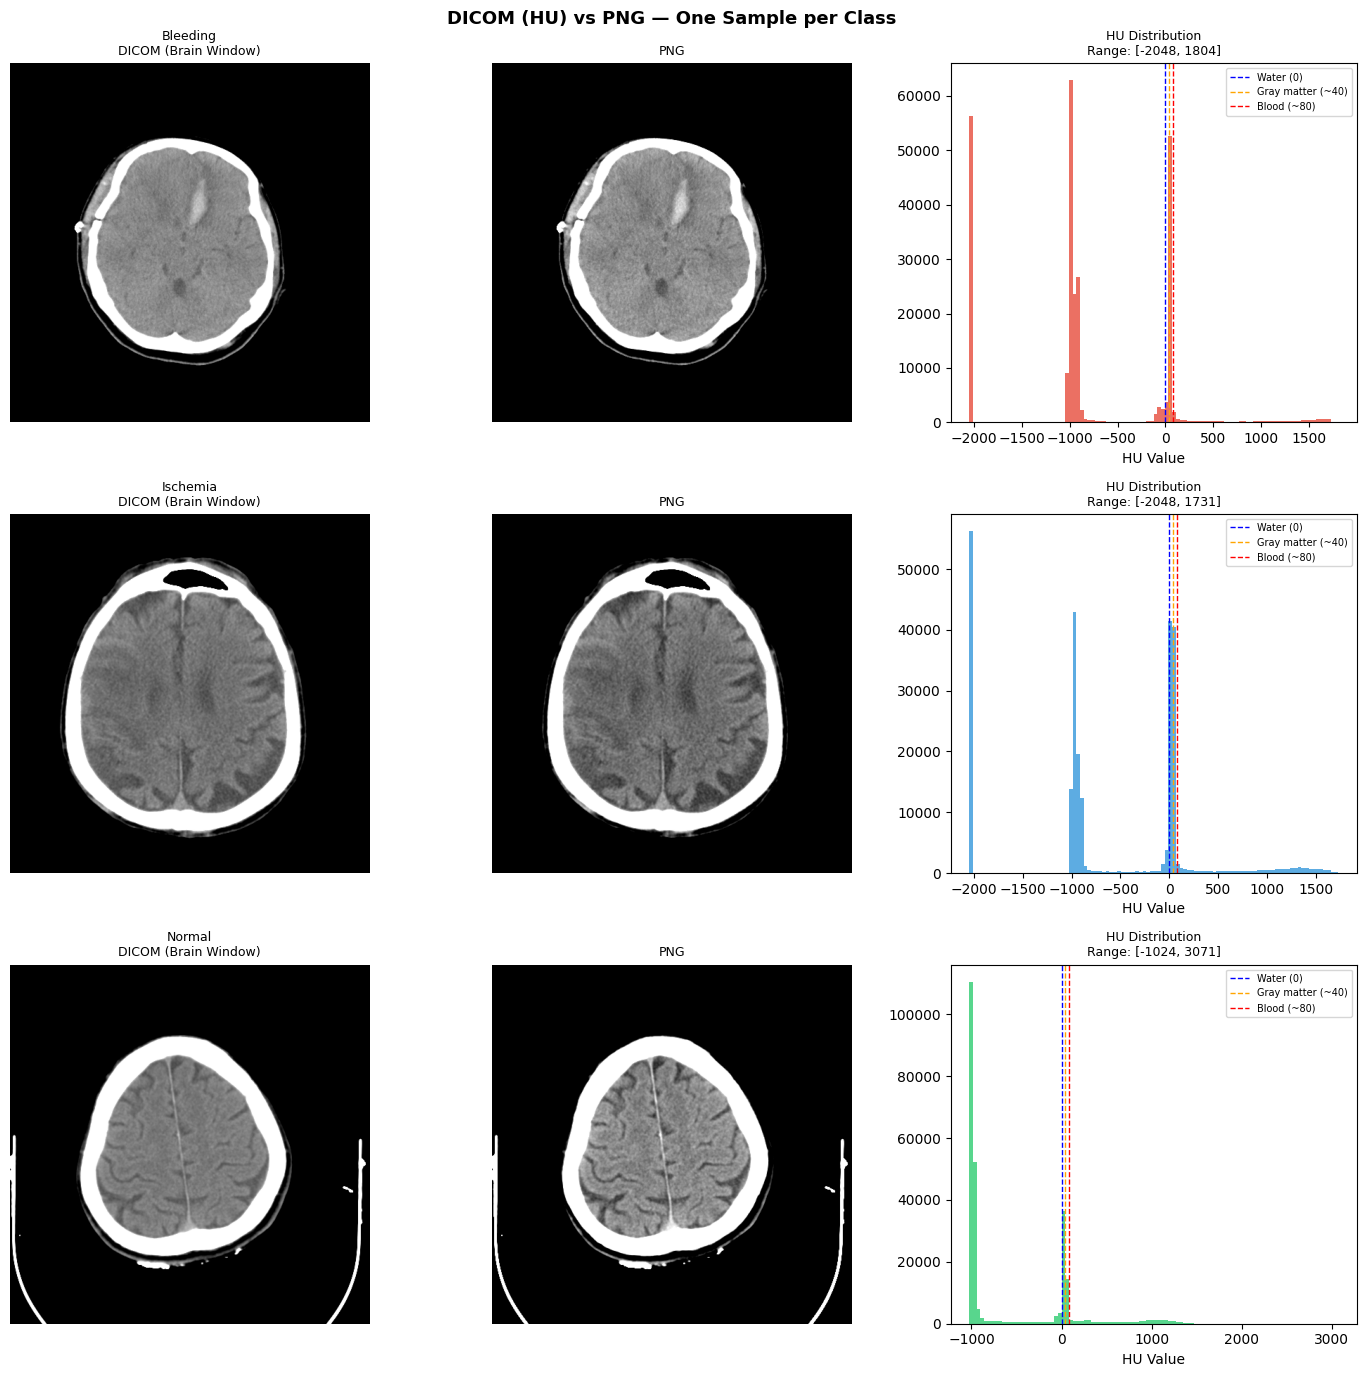

In [12]:
def dicom_to_hu(ds):
    """Convert raw DICOM pixel array to Hounsfield Units."""
    intercept = getattr(ds, 'RescaleIntercept', 0)
    slope     = getattr(ds, 'RescaleSlope', 1)
    return ds.pixel_array * slope + intercept

fig, axes = plt.subplots(3, 3, figsize=(14, 14))
fig.suptitle('DICOM (HU) vs PNG — One Sample per Class', fontsize=13, fontweight='bold')

for row, cls in enumerate(CLASSES):
    dcm_file  = sorted(paths[cls]['DICOM'].iterdir())[0]
    png_file  = paths[cls]['PNG'] / (dcm_file.stem + '.png')

    ds  = pydicom.dcmread(dcm_file)
    hu  = dicom_to_hu(ds)
    png = np.array(Image.open(png_file).convert('L')) if png_file.exists() else None

    # DICOM HU image (window to brain window: 40±80)
    wc, ww = 40, 80
    hu_clipped = np.clip(hu, wc - ww, wc + ww)
    hu_norm    = ((hu_clipped - hu_clipped.min()) / (hu_clipped.max() - hu_clipped.min() + 1e-8) * 255).astype(np.uint8)

    axes[row][0].imshow(hu_norm, cmap='gray')
    axes[row][0].set_title(f'{cls}\nDICOM (Brain Window)', fontsize=9)
    axes[row][0].axis('off')

    if png is not None:
        axes[row][1].imshow(png, cmap='gray')
        axes[row][1].set_title('PNG', fontsize=9)
        axes[row][1].axis('off')

    # HU histogram
    axes[row][2].hist(hu.ravel(), bins=100, color=list(cls_colors.values())[row], alpha=0.8)
    axes[row][2].set_title(f'HU Distribution\nRange: [{hu.min():.0f}, {hu.max():.0f}]', fontsize=9)
    axes[row][2].set_xlabel('HU Value')
    axes[row][2].axvline(0,   color='blue',  linestyle='--', linewidth=1, label='Water (0)')
    axes[row][2].axvline(40,  color='orange',linestyle='--', linewidth=1, label='Gray matter (~40)')
    axes[row][2].axvline(80,  color='red',   linestyle='--', linewidth=1, label='Blood (~80)')
    axes[row][2].legend(fontsize=7)

plt.tight_layout()
plt.savefig(ROOT.parent / 'dicom_vs_png.png', dpi=150, bbox_inches='tight')
plt.show()

So this figure tells that:
* PNG looks visually similar to brain-windowed DICOM.
* The underlying DICOM still contains full HU physics information, which is richer than PNG grayscale.

## 9. Overlay Format Analysis

In [13]:
print("Overlay/Mask format analysis:\n")
for cls in ['Bleeding', 'Ischemia', 'External_Test']:
    key = 'OVERLAY' if cls != 'External_Test' else 'MASKS'
    folder = paths[cls][key] if key in paths[cls] else None
    if folder is None:
        continue
    files = sorted(folder.iterdir())[:5]
    print(f"{cls}/{key}:")
    for f in files:
        img = np.array(Image.open(f))
        unique_vals = np.unique(img).tolist()
        # Only show first 10 unique vals
        if len(unique_vals) > 10:
            unique_vals = unique_vals[:10] + ['...']
        print(f"  {f.name}: shape={img.shape}, dtype={img.dtype}, unique_vals={unique_vals}")
    print()

Overlay/Mask format analysis:

Bleeding/OVERLAY:
  10002.png: shape=(512, 512, 4), dtype=uint8, unique_vals=[0, 2, 4, 6, 9, 11, 13, 15, 17, 19, '...']
  10033.png: shape=(512, 512, 4), dtype=uint8, unique_vals=[0, 2, 4, 6, 9, 11, 13, 15, 17, 19, '...']
  10036.png: shape=(512, 512, 4), dtype=uint8, unique_vals=[0, 3, 6, 10, 13, 16, 19, 23, 26, 29, '...']
  10039.png: shape=(512, 512, 4), dtype=uint8, unique_vals=[0, 2, 3, 4, 5, 7, 8, 10, 13, 15, '...']
  10045.png: shape=(512, 512, 4), dtype=uint8, unique_vals=[0, 3, 5, 8, 10, 13, 15, 18, 20, 21, '...']

Ischemia/OVERLAY:
  10003.png: shape=(512, 512, 4), dtype=uint8, unique_vals=[0, 2, 4, 6, 9, 11, 13, 15, 17, 19, '...']
  10017.png: shape=(512, 512, 4), dtype=uint8, unique_vals=[0, 3, 5, 6, 8, 9, 10, 11, 13, 14, '...']
  10024.png: shape=(512, 512, 4), dtype=uint8, unique_vals=[0, 3, 5, 8, 10, 13, 15, 18, 21, 23, '...']
  10028.png: shape=(512, 512, 4), dtype=uint8, unique_vals=[0, 3, 6, 10, 13, 16, 19, 22, 23, 24, '...']
  10038.png

## 10. Summary

In [14]:
print("="*55)
print("DATASET SUMMARY")
print("="*55)
print(f"  Classes          : Bleeding, Ischemia, Normal")
print(f"  Training images  : {total_train:,} PNG files")
print(f"  External test    : {counts['External_Test'].get('PNG', 0)} images (with masks)")
print(f"  Overlays avail.  : Bleeding ({counts['Bleeding'].get('OVERLAY',0)}), "
      f"Ischemia ({counts['Ischemia'].get('OVERLAY',0)})")
print(f"  Class imbalance  : Normal is ~4x larger than stroke classes")
print()
print("Next steps:")
print("  1. Build DataLoader (PNG-based, with class weights for imbalance)")
print("  2. Binarize OVERLAY images for segmentation ground truth")
print("  3. Train classification model (EfficientNet/ResNet)")
print("  4. Train segmentation model (U-Net) on Bleeding + Ischemia")
print("  5. Evaluate both models on External_Test")

DATASET SUMMARY
  Classes          : Bleeding, Ischemia, Normal
  Training images  : 6,650 PNG files
  External test    : 200 images (with masks)
  Overlays avail.  : Bleeding (1093), Ischemia (1130)
  Class imbalance  : Normal is ~4x larger than stroke classes

Next steps:
  1. Build DataLoader (PNG-based, with class weights for imbalance)
  2. Binarize OVERLAY images for segmentation ground truth
  3. Train classification model (EfficientNet/ResNet)
  4. Train segmentation model (U-Net) on Bleeding + Ischemia
  5. Evaluate both models on External_Test
